# Statistical Similarity Results – Visualizations

Visualizations of the four SDV models (**CTGAN**, **CopulaGAN**, **Gaussian Copula**, **TVAE**) for each dataset: **Bank**, **Cancer**, and **Alzhimers**.

Data source: `statistical_similarity_results.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Output folder for figures
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Load results
csv_path = Path('statistical_similarity_results.csv')
df = pd.read_csv(csv_path)

# Normalize dataset name for display (Bank -> Banking)
df['Dataset_Display'] = df['Dataset'].replace({'Bank': 'Banking'})

MODELS = ['CTGAN', 'CopulaGAN', 'GaussianCopula', 'TVAE']
DATASETS = ['Bank', 'Cancer', 'Alzhimers']
DATASET_LABELS = {'Bank': 'Banking', 'Cancer': 'Cancer', 'Alzhimers': 'Alzhimers'}

print('Loaded rows:', len(df))
print('Datasets:', df['Dataset'].unique().tolist())
print('Models:', df['Model'].unique().tolist())
df.head()

Loaded rows: 192
Datasets: ['Bank', 'Cancer', 'Alzhimers']
Models: ['CTGAN', 'CopulaGAN', 'GaussianCopula', 'TVAE']


,Dataset,Model,Column,Mean_Real,Mean_Synthetic,Mean_Error_%,Median_Real,Median_Synthetic,Median_Error_%,Std_Real,Std_Synthetic,Std_Error_%,Outliers_Real,Outliers_Synthetic,Outliers_Diff,Dataset_Display
0,Bank,CTGAN,age,39.7254,41.1644,3.622368,38.0,40.0,5.263158,9.327813,9.184814,1.533039,0,0,0,Banking
1,Bank,CTGAN,campaign,2.6193,2.3537,10.140114,2.0,2.0,0.000000,2.997844,2.059277,31.308069,582,280,302,Banking
2,Bank,CTGAN,previous,0.0000,0.0000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0,0,Banking
3,Bank,CTGAN,balance,1117.0699,1395.0201,24.882078,355.0,346.0,2.535211,2647.588498,3139.675017,18.586216,1108,1058,50,Banking
4,Bank,CTGAN,duration,262.1082,305.7708,16.658235,189.0,208.0,10.052910,252.148595,305.213532,21.045105,731,843,112,Banking


## 1. Average error by model (per dataset)

Bar charts: **Mean Error %**, **Median Error %**, **Std Error %** averaged over all features for each of the four models.

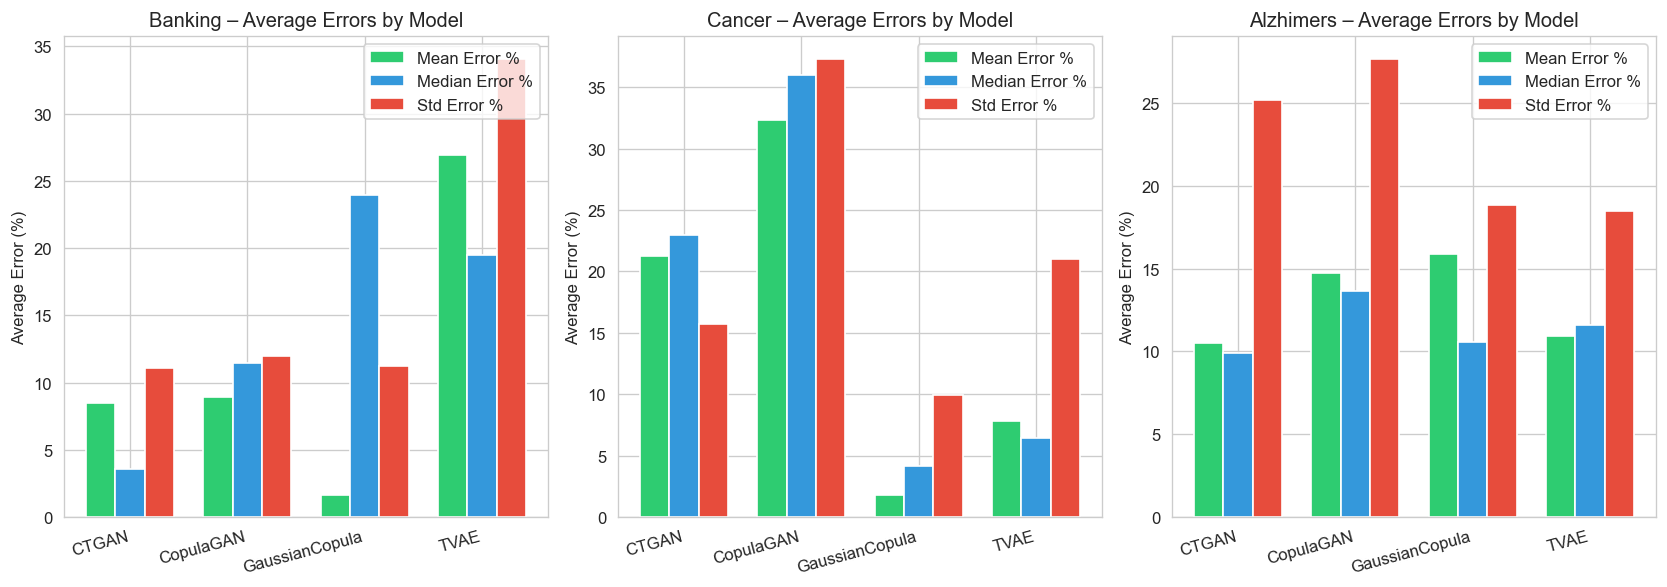

In [2]:
def plot_avg_errors_by_dataset(dataset_name, ax=None):
    subset = df[df['Dataset'] == dataset_name]
    if subset.empty:
        return
    
    agg = subset.groupby('Model').agg({
        'Mean_Error_%': 'mean',
        'Median_Error_%': 'mean',
        'Std_Error_%': 'mean'
    }).reindex(MODELS).fillna(0)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    
    x = np.arange(len(MODELS))
    w = 0.25
    
    ax.bar(x - w, agg['Mean_Error_%'], width=w, label='Mean Error %', color='#2ecc71')
    ax.bar(x,     agg['Median_Error_%'], width=w, label='Median Error %', color='#3498db')
    ax.bar(x + w, agg['Std_Error_%'], width=w, label='Std Error %', color='#e74c3c')
    
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=15, ha='right')
    ax.set_ylabel('Average Error (%)')
    ax.set_title(f'{DATASET_LABELS.get(dataset_name, dataset_name)} – Average Errors by Model')
    ax.legend(loc='upper right')
    ax.set_ylim(0, None)
    plt.tight_layout()
    return ax


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, ds in enumerate(DATASETS):
    plot_avg_errors_by_dataset(ds, ax=axes[i])
plt.tight_layout()
plt.savefig(FIG_DIR / 'figures_by_dataset_avg_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Single metric comparison: Mean Error % by model (per dataset)

One bar chart per dataset showing only **Mean Error %** for the four models.

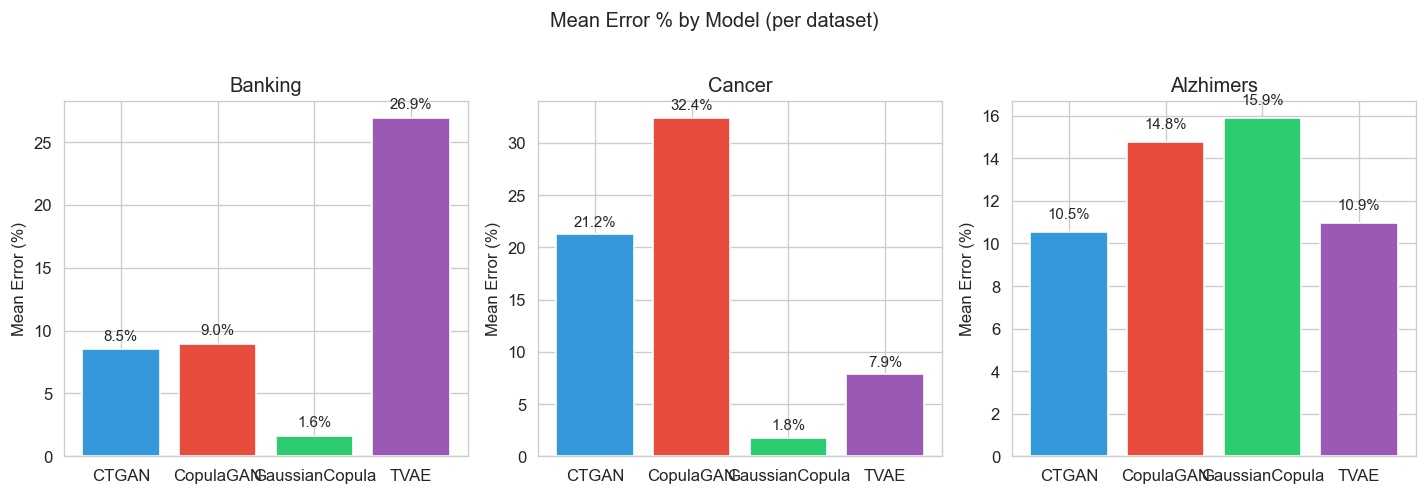

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, ds in enumerate(DATASETS):
    subset = df[df['Dataset'] == ds]
    agg = subset.groupby('Model')['Mean_Error_%'].mean().reindex(MODELS).fillna(0)
    
    bars = axes[i].bar(MODELS, agg.values, color=colors)
    axes[i].set_ylabel('Mean Error (%)')
    axes[i].set_title(f'{DATASET_LABELS.get(ds, ds)}')
    axes[i].set_ylim(0, None)
    for b, v in zip(bars, agg.values):
        axes[i].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Mean Error % by Model (per dataset)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figures_mean_error_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Box plots: distribution of errors per model (per dataset)

Distribution of **Mean Error %** across features for each model.

C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_21800\2292093702.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Model', y='Mean_Error_%', order=order, ax=axes[i], palette='Set2')
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_21800\2292093702.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Model', y='Mean_Error_%', order=order, ax=axes[i], palette='Set2')
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_21800\2292093702.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x=

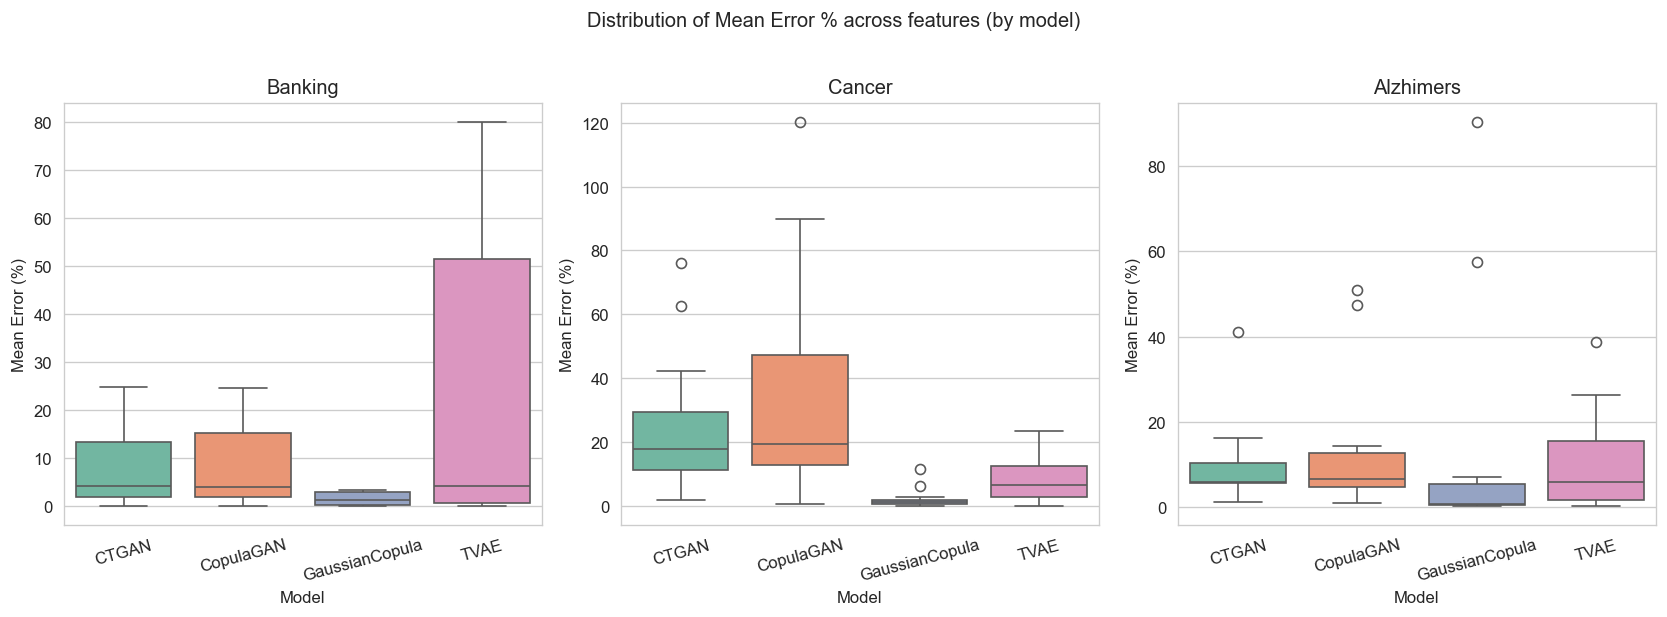

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, ds in enumerate(DATASETS):
    subset = df[df['Dataset'] == ds]
    order = [m for m in MODELS if m in subset['Model'].unique()]
    sns.boxplot(data=subset, x='Model', y='Mean_Error_%', order=order, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{DATASET_LABELS.get(ds, ds)}')
    axes[i].set_ylabel('Mean Error (%)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Distribution of Mean Error % across features (by model)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figures_boxplot_mean_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Heatmaps: error by model and feature (per dataset)

Heatmap of **Mean Error %** (models vs features) for each dataset. Features with many columns are truncated for readability.

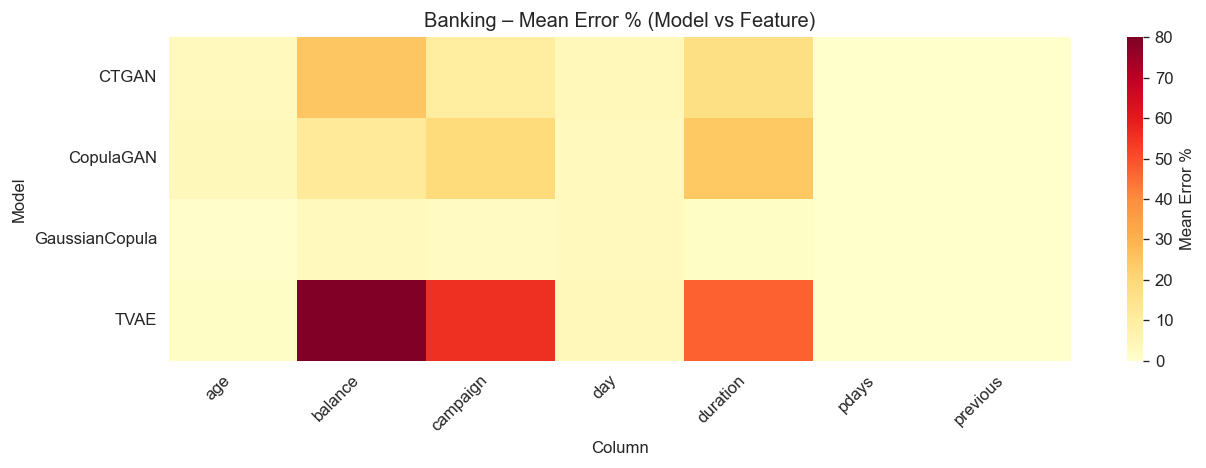

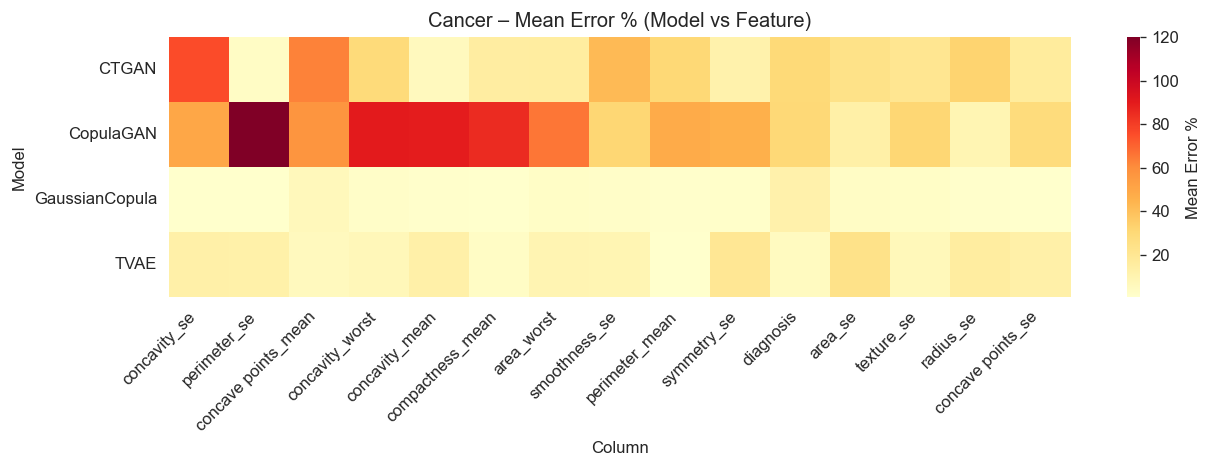

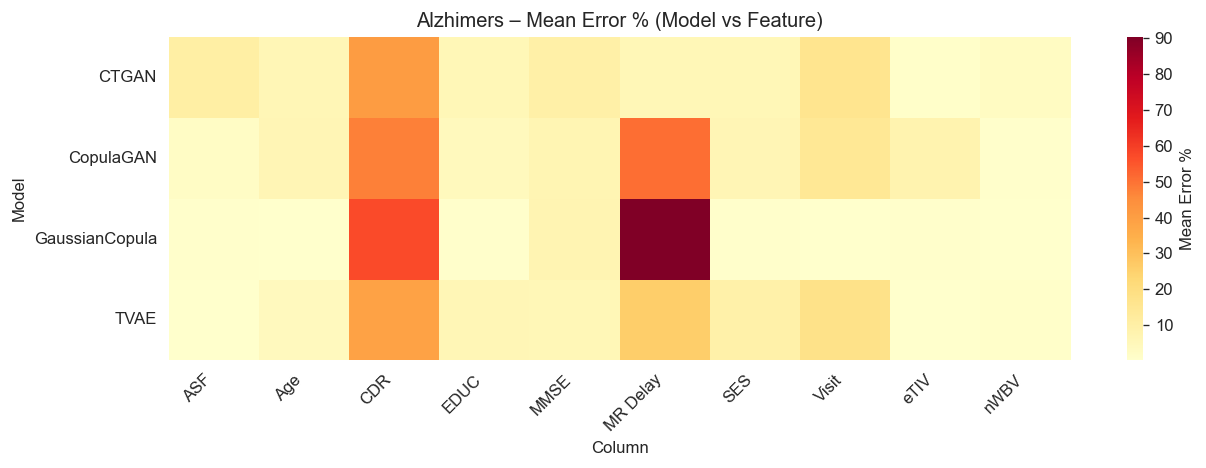

In [5]:
def plot_heatmap_dataset(dataset_name, max_features=20, figsize=(10, 4)):
    subset = df[df['Dataset'] == dataset_name]
    if subset.empty:
        return None
    
    pivot = subset.pivot_table(index='Model', columns='Column', values='Mean_Error_%')
    pivot = pivot.reindex(MODELS)
    
    # Limit columns for readability
    if pivot.shape[1] > max_features:
        col_means = pivot.mean().sort_values(ascending=False)
        cols = col_means.head(max_features).index.tolist()
        pivot = pivot[cols]
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot, annot=False, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Mean Error %'})
    ax.set_title(f'{DATASET_LABELS.get(dataset_name, dataset_name)} – Mean Error % (Model vs Feature)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return fig

for ds in DATASETS:
    fig = plot_heatmap_dataset(ds, max_features=15, figsize=(11, 4))
    if fig:
        fig.savefig(FIG_DIR / f'figure_heatmap_{ds}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 5. Radar-style summary: one plot per dataset

Normalized scores for Mean, Median, and Std errors (lower is better). Each axis = one metric; each model = one polygon.

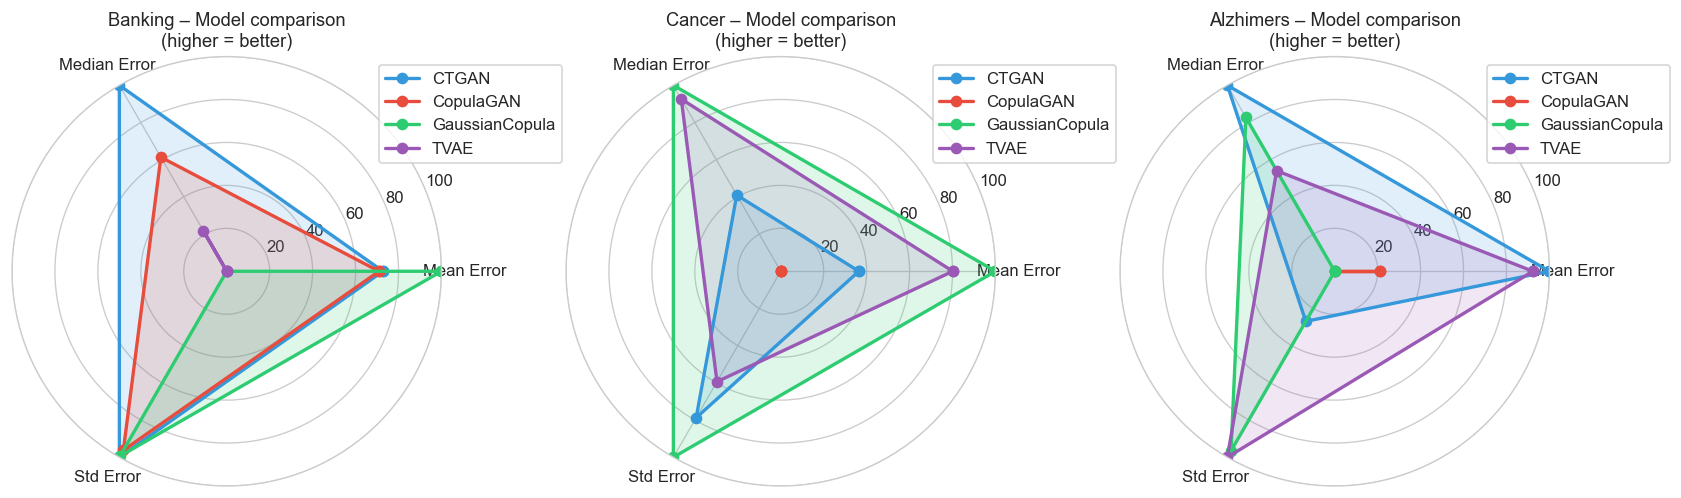

In [6]:
def plot_radar_dataset(dataset_name, ax=None):
    subset = df[df['Dataset'] == dataset_name]
    if subset.empty:
        return None
    
    agg = subset.groupby('Model').agg({
        'Mean_Error_%': 'mean',
        'Median_Error_%': 'mean',
        'Std_Error_%': 'mean'
    }).reindex(MODELS).fillna(0)
    
    # Normalize so lower error = higher score (100 - min-max scaled), then 0-100
    def norm_lower_better(s):
        m, M = s.min(), s.max()
        if M == m:
            return pd.Series(100, index=s.index)
        return 100 - (s - m) / (M - m) * 100
    
    agg_norm = agg.apply(norm_lower_better)
    
    categories = ['Mean Error', 'Median Error', 'Std Error']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(projection='polar'))
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
    for (model, row), c in zip(agg_norm.iterrows(), colors):
        values = [row['Mean_Error_%'], row['Median_Error_%'], row['Std_Error_%']] + [row['Mean_Error_%']]
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=c)
        ax.fill(angles, values, alpha=0.15, color=c)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 100)
    ax.set_title(f'{DATASET_LABELS.get(dataset_name, dataset_name)} – Model comparison\n(higher = better)', fontsize=11)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    return ax

fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw=dict(projection='polar'))
for i, ds in enumerate(DATASETS):
    plot_radar_dataset(ds, ax=axes[i])
plt.tight_layout()
plt.savefig(FIG_DIR / 'figures_radar_by_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Outlier difference by model (per dataset)

Average absolute difference in outlier counts (Real vs Synthetic) by model.

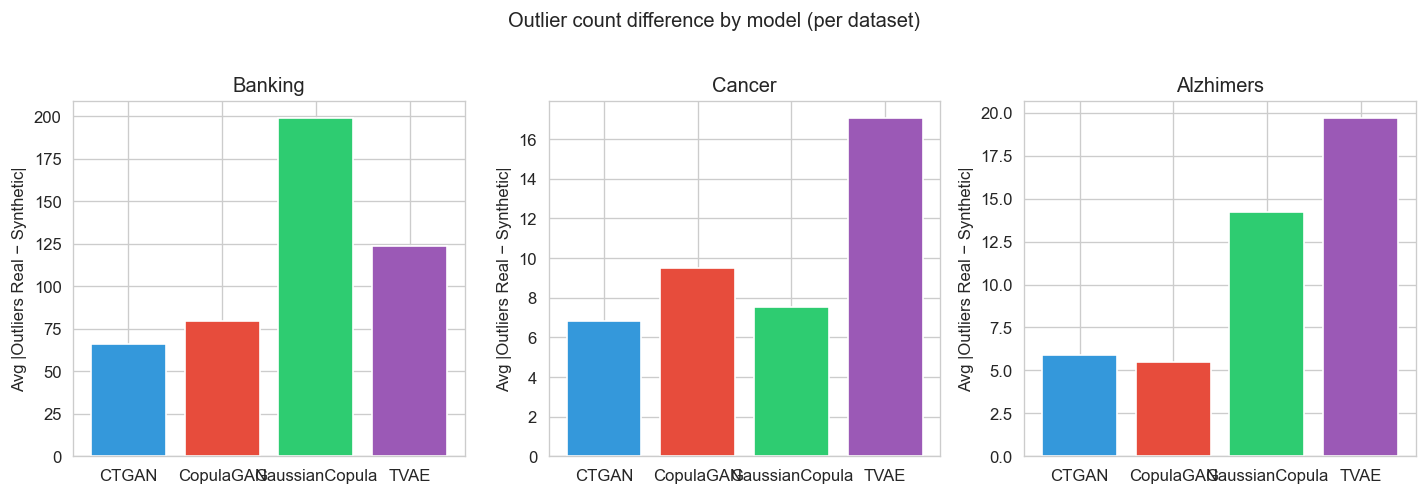

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, ds in enumerate(DATASETS):
    subset = df[df['Dataset'] == ds]
    agg = subset.groupby('Model')['Outliers_Diff'].mean().reindex(MODELS).fillna(0)
    
    bars = axes[i].bar(MODELS, agg.values, color=colors)
    axes[i].set_ylabel('Avg |Outliers Real − Synthetic|')
    axes[i].set_title(f'{DATASET_LABELS.get(ds, ds)}')
    axes[i].set_ylim(0, None)

plt.suptitle('Outlier count difference by model (per dataset)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures_outliers_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Combined dashboard: one figure per dataset

For each dataset: one row with (1) Average errors bar chart, (2) Mean Error % box plot.

C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_21800\1916030595.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Model', y='Mean_Error_%', order=order, ax=ax2, palette='Set2')


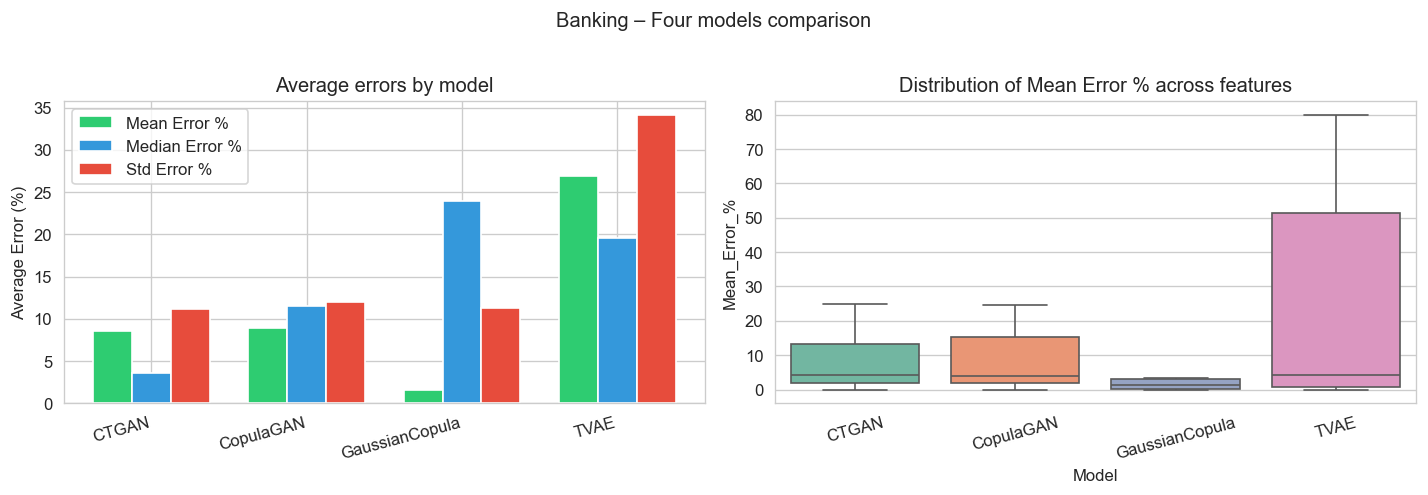

C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_21800\1916030595.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Model', y='Mean_Error_%', order=order, ax=ax2, palette='Set2')


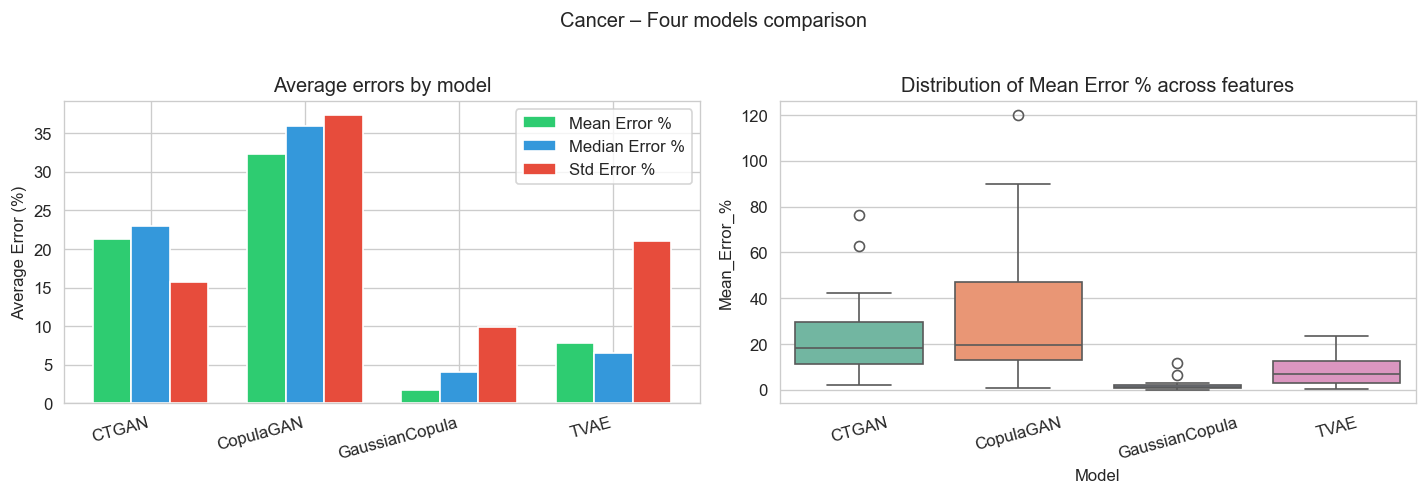

C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_21800\1916030595.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Model', y='Mean_Error_%', order=order, ax=ax2, palette='Set2')


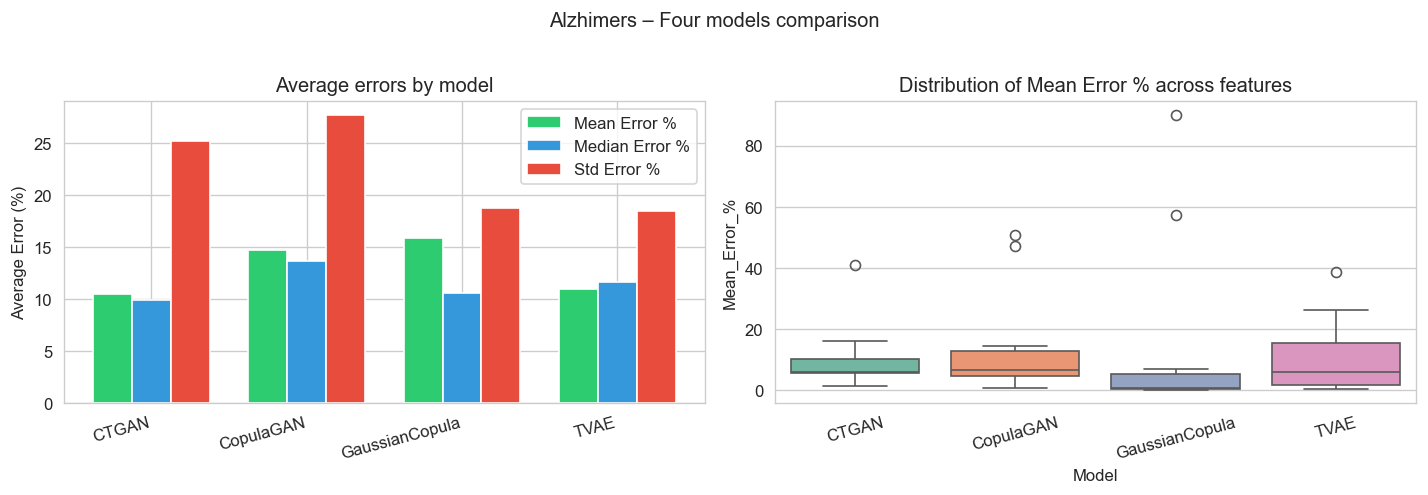

In [8]:
for ds in DATASETS:
    subset = df[df['Dataset'] == ds]
    if subset.empty:
        continue
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left: average errors by model
    agg = subset.groupby('Model').agg({
        'Mean_Error_%': 'mean', 'Median_Error_%': 'mean', 'Std_Error_%': 'mean'
    }).reindex(MODELS).fillna(0)
    x = np.arange(len(MODELS))
    w = 0.25
    ax1.bar(x - w, agg['Mean_Error_%'], width=w, label='Mean Error %', color='#2ecc71')
    ax1.bar(x,     agg['Median_Error_%'], width=w, label='Median Error %', color='#3498db')
    ax1.bar(x + w, agg['Std_Error_%'], width=w, label='Std Error %', color='#e74c3c')
    ax1.set_xticks(x)
    ax1.set_xticklabels(MODELS, rotation=15, ha='right')
    ax1.set_ylabel('Average Error (%)')
    ax1.set_title('Average errors by model')
    ax1.legend()
    ax1.set_ylim(0, None)
    
    # Right: box plot
    order = [m for m in MODELS if m in subset['Model'].unique()]
    sns.boxplot(data=subset, x='Model', y='Mean_Error_%', order=order, ax=ax2, palette='Set2')
    ax2.set_title('Distribution of Mean Error % across features')
    ax2.tick_params(axis='x', rotation=15)
    
    fig.suptitle(f'{DATASET_LABELS.get(ds, ds)} – Four models comparison', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'figure_dashboard_{ds}.png', dpi=150, bbox_inches='tight')
    plt.show()